<table class="table table-bordered">
    <tr>        
         <th style="text-align:center;"><h1>IS217 Case Study</h1></th>
    </tr>
    <tr>
        <th style="text-align:center;"><h1>Multiple Linear Regression using Car Dataset</h1></th>
    </tr>
</table>

**In this auto-mpg dataset about cars, the goal is to build a regression model to predict the `mpg`(target) for cars using given input variables (independent variables/predictors). The data definition is given below -** <br>


| Variable | Label | Type |
| --- | ----- | --- |
| MPG | Gas mileage in miles per gallon | Numerical|
| Cylinders | Number of cylinders | Numerical (Discrete)|
| Displacement | Engine size in cubic inches | Numerical|
|HorsePower	|Engine power in HP	|Numerical|
|Weight|  Curb weight in lb |Numerical|
|Acceleration|	From 0 to 60mph in seconds|	Numerical|
|ModelYear|	Year of manufacture|Numerical (Discrete)|
|Origin|	Geo location |	Categorical|
|CarName| Model name| Categorical|

**Instructions:** <br>
 1. Use the auto-mpg.csv dataset
 2. Using appropriate python functions/libraries answer the Questions provided. Use this notebook for coding.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#%matplotlib inline

### Reading the Data, EDA, and Data Preparation

**Q1 : <br>
Load the data from auto-mpg.csv. In which variable(s) do you find missing values? <br>**
a.	MPG <br>
b.	Cylinders<br>
c.	Displacement<br>
d.	Horsepower 	<br>
e.	Weight


In [2]:
#Read the dataset
# Use auto as the name of your DataFrame
auto = pd.read_csv('auto-mpg.csv')
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           276 non-null    float64
 1   Cylinders     276 non-null    int64  
 2   Displacement  276 non-null    int64  
 3   HorsePower    271 non-null    float64
 4   Weight        276 non-null    int64  
 5   Acceleration  276 non-null    float64
 6   ModelYear     276 non-null    int64  
 7   Origin        276 non-null    int64  
 8   CarName       276 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 19.5+ KB


In [3]:
auto.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
HorsePower      5
Weight          0
Acceleration    0
ModelYear       0
Origin          0
CarName         0
dtype: int64

**Note:** Even though origin is a categorical data, the Dtype is said to be int64. Note this difference.

#### Using basic EDA functions e.g., head(), hist(), describe(), understand the data before proceeding to the other questions

In [4]:
#Using basic EDA functions understand the data
auto.head()

,MPG,Cylinders,Displacement,HorsePower,Weight,Acceleration,ModelYear,Origin,CarName
0,27.0,4,97,88.0,2130,14.5,71,3,datsun pl510
1,28.0,4,140,90.0,2264,15.5,71,1,chevrolet vega 2300
2,25.0,4,113,95.0,2228,14.0,71,3,toyota corona
3,25.0,4,98,NaN,2046,19.0,71,1,ford pinto
4,21.0,4,120,87.0,2979,19.5,72,2,peugeot 504 (sw)


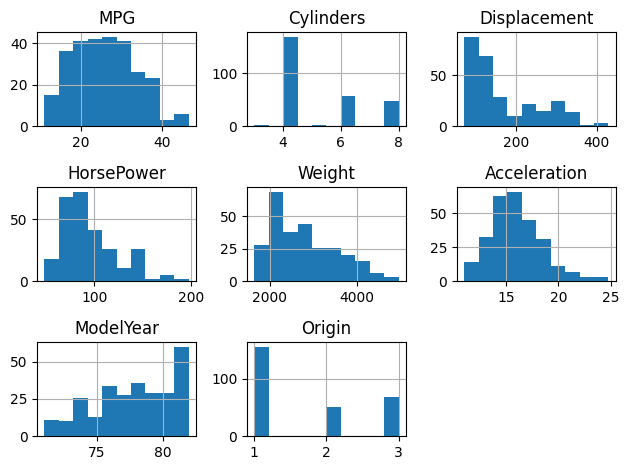

In [5]:
# when i do histogram, it will automatically only show numerical data
# likewise, when you use describe, it only shows numerical, you need to add include=all
auto.hist()
plt.tight_layout()

In [6]:
auto.describe(include='all')

,MPG,Cylinders,Displacement,HorsePower,Weight,Acceleration,ModelYear,Origin,CarName
count,276.000000,276.000000,276.000000,271.000000,276.000000,276.000000,276.000000,276.000000,276
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,226
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,toyota corona
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
mean,25.879710,5.090580,167.630435,94.933579,2798.351449,15.987681,77.778986,1.684783,NaN
std,7.561425,1.540644,86.174924,29.404006,732.747087,2.468403,2.881615,0.847619,NaN
min,11.000000,3.000000,70.000000,48.000000,1649.000000,11.000000,71.000000,1.000000,NaN
25%,19.975000,4.000000,98.000000,73.000000,2163.000000,14.475000,76.000000,1.000000,NaN
50%,25.650000,4.000000,134.500000,88.000000,2667.500000,15.800000,78.000000,1.000000,NaN
75%,31.650000,6.000000,231.000000,110.000000,3354.750000,17.300000,80.000000,2.250000,NaN


**Q2: What is the median of Model Year of the cars?**<br>

In [7]:
auto['ModelYear'].median()

78.0

**Q3: Inspect the variable Origin and CarName of the first 15 data points. Match the values in Origin to geographical locations based on your domain knowledge. <br>
Hint: Here domain refers to information on which cars or manufacturuers are prevalent in which regions. Look for matching options.** <br>

Origin 1: America <br>
Origin 2: Europe <br>
Origin 3: Asia <br>

Options:<br>
a) Europe<br>
b) Asia<br>
c) America<br>

In [8]:
## Inspect the values in Origin and CarName
auto[['Origin', 'CarName']].head(15)

,Origin,CarName
0,3,datsun pl510
1,1,chevrolet vega 2300
2,3,toyota corona
3,1,ford pinto
4,2,peugeot 504 (sw)
5,2,renault 12 (sw)
6,1,ford pinto (sw)
7,3,datsun 510 (sw)
8,3,toyouta corona mark ii (sw)
9,1,dodge colt (sw)


**Q4 <br> 
What is the mean value of `Displacement` for the observations with missing values in column identified in Q1?** <br>
a) 25.87<br>
b) 94.93<br>
c) 110.6<br>
d) 167.63<br>

In [9]:
auto[auto['HorsePower'].isnull()]['Displacement'].mean()

np.float64(110.6)

In [10]:
# Step 1: extract those records where the Horsepower is null ie missing values
auto['HorsePower'].isnull() 
# False if there is a value and true if there is no value (aka missing)

0      False
1      False
2      False
3       True
4      False
       ...  
271    False
272    False
273    False
274    False
275    False
Name: HorsePower, Length: 276, dtype: bool

In [11]:
# Step 2: Apply boolena indexing to filter DataFrame to only those rows with HorsePower is null
auto[auto['HorsePower'].isnull()]

,MPG,Cylinders,Displacement,HorsePower,Weight,Acceleration,ModelYear,Origin,CarName
3,25.0,4,98,NaN,2046,19.0,71,1,ford pinto
208,40.9,4,85,NaN,1835,17.3,80,2,renault lecar deluxe
214,23.6,4,130,NaN,2905,14.3,80,1,ford mustang cobra
232,34.5,4,100,NaN,2320,15.8,81,2,renault 18i
252,23.0,4,140,NaN,3035,20.5,82,1,amc concord dl


In [12]:
# Step 3: Find the mean of Displacement for the rows that have been selected
auto[auto['HorsePower'].isnull()]['Displacement'].mean()

np.float64(110.6)

#### **Before proceeding to perform MLR, impute missing values for HorsePower : <br>**
In this scenario, we will use other predictor variables to estimate the missing values in **Horsepower**. Based on domain knowledge, **Displacement** is a suitable candidate for this purpose. We assume that **Horsepower** can be inferred from observations with similar **Displacement** values, using data from rows where **Horsepower** is not missing.
 
**Follow below steps to perform this task :** 
1. Use pd.cut() to bin **HorsePower** into 4 bins and give labels as say - bin-1, bin-2, bin-3, bin-4. Save these labels in a new column in the  data as `HP-bins`. You can see that the missing values have been assigned NAN for labels.
2. Groupby using `HP-bins` and find the `mean()` of **Displacement** and **HorsePower** to 2 decimal places.
3. Identify the bin in which the mean value of **Displacement** is closest to the mean value **Displacement** in the missing horsepower bin as found in **Q4**.
4. Fill the missing values with the mean HorsePower value from the bin identified in step 3.



**Q5. What is the value used to replace the missing HorsePower.**<br>

a. 70.87<br>
b. 98.92 <br>
c. 85.0 <br>
d. 31.71

**Hint:** Use pd.cut on the HorsePower column with the parameters bins = 4 and labels = [bin-1, bin-2, bin-3, bin-4]. Assign the result of pd.cut to a new column 'HP-bins' in the auto dataFrame

In [13]:
#Create the bins and apply Groupby. Help code on cut is given in the following commented code
#Assuming auto is the name of the DataFrame, we have:
auto['HP-bins'] = pd.cut(auto['HorsePower'].to_numpy(), bins = 4, labels = ['bin-1', 'bin-2', 'bin-3', 'bin-4'])
auto.head()

,MPG,Cylinders,Displacement,HorsePower,Weight,Acceleration,ModelYear,Origin,CarName,HP-bins
0,27.0,4,97,88.0,2130,14.5,71,3,datsun pl510,bin-2
1,28.0,4,140,90.0,2264,15.5,71,1,chevrolet vega 2300,bin-2
2,25.0,4,113,95.0,2228,14.0,71,3,toyota corona,bin-2
3,25.0,4,98,NaN,2046,19.0,71,1,ford pinto,NaN
4,21.0,4,120,87.0,2979,19.5,72,2,peugeot 504 (sw),bin-2


In [14]:
# Now, Groupby using 'HP-bins'
# For some version of Pandas, you need to set groupby parameter 'observed = False'
# This will show all values for categorical groupers (to remove a warning but not necessary in our scenario)
auto.groupby('HP-bins', observed=False)[['Displacement','HorsePower']].mean().round(2)

,Displacement,HorsePower
HP-bins,,
bin-1,109.33,70.87
bin-2,171.17,98.92
bin-3,307.87,141.32
bin-4,357.50,179.75


In [15]:
# Observe which bin has the closest match to the mean value found in Q4, then fill the missing values
# Reminder: remember to use inplace = True if u directly use fillna() function without assigning to a new variable
auto[auto['HorsePower'].isna()]

,MPG,Cylinders,Displacement,HorsePower,Weight,Acceleration,ModelYear,Origin,CarName,HP-bins
3,25.0,4,98,NaN,2046,19.0,71,1,ford pinto,NaN
208,40.9,4,85,NaN,1835,17.3,80,2,renault lecar deluxe,NaN
214,23.6,4,130,NaN,2905,14.3,80,1,ford mustang cobra,NaN
232,34.5,4,100,NaN,2320,15.8,81,2,renault 18i,NaN
252,23.0,4,140,NaN,3035,20.5,82,1,amc concord dl,NaN


In [16]:
auto['HorsePower'] = auto['HorsePower'].fillna(70.87)
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   MPG           276 non-null    float64 
 1   Cylinders     276 non-null    int64   
 2   Displacement  276 non-null    int64   
 3   HorsePower    276 non-null    float64 
 4   Weight        276 non-null    int64   
 5   Acceleration  276 non-null    float64 
 6   ModelYear     276 non-null    int64   
 7   Origin        276 non-null    int64   
 8   CarName       276 non-null    object  
 9   HP-bins       271 non-null    category
dtypes: category(1), float64(3), int64(5), object(1)
memory usage: 20.0+ KB


#### Create Pair Plots using Seaborn for the variables in the data. 

**Q6. Which of of the following variables appears to have curvilinear relationship with MPG?**<br>

a) Cylinders<br>
b) **Displacement**<br>
c) **HorsePower**<br>
d) **Weight**<br>
e) ModelYear<br>

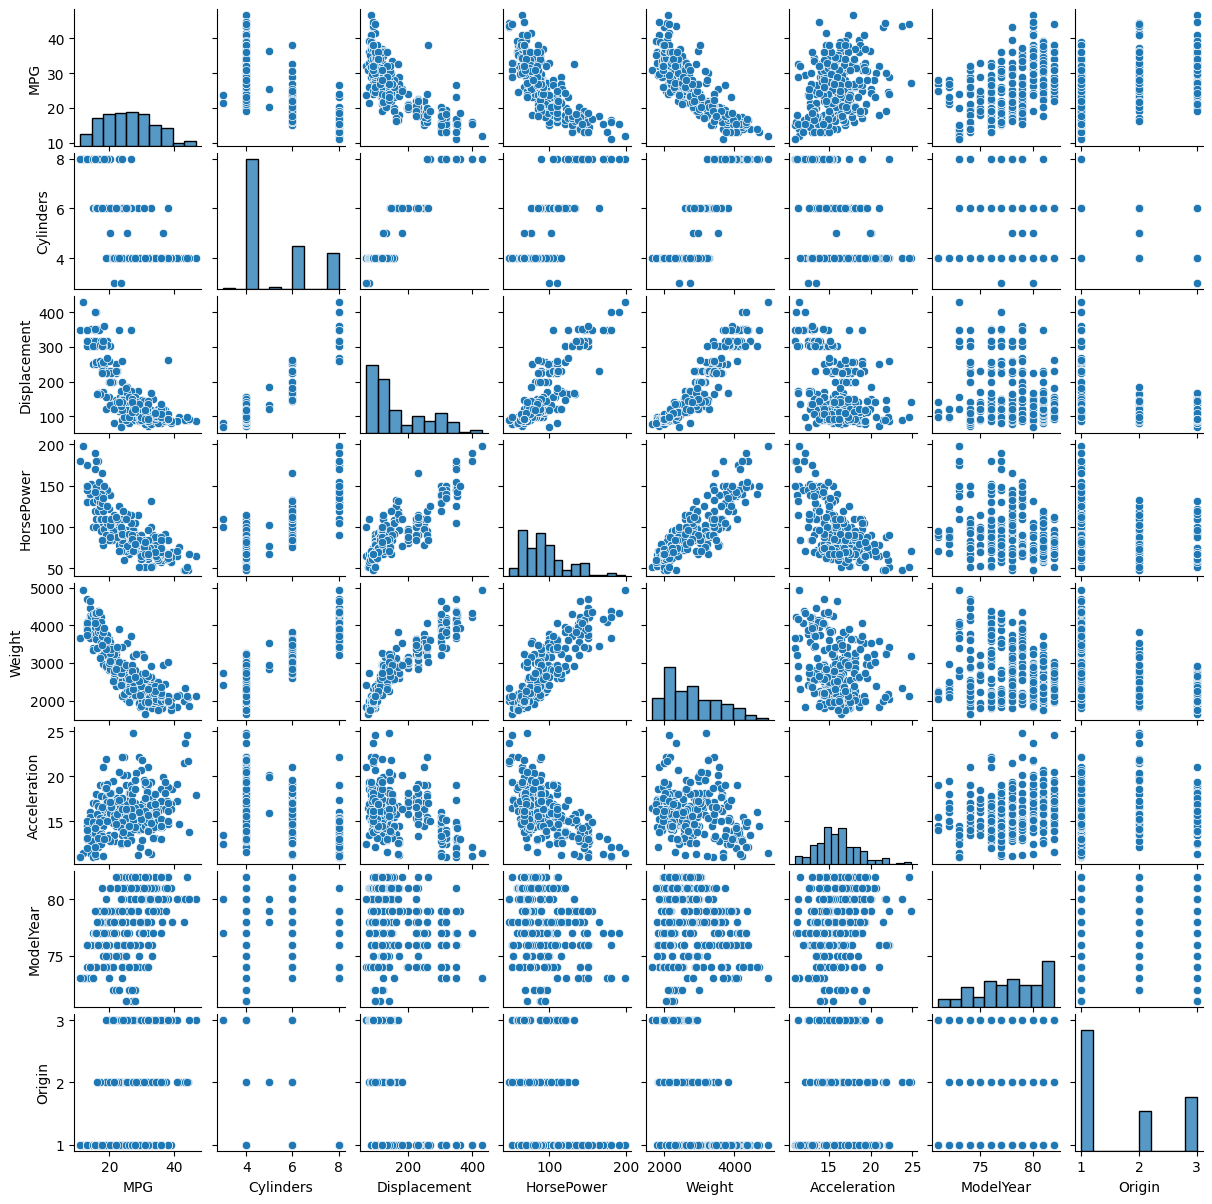

In [17]:
# Hint: using sns pairplot
f = sns.pairplot(auto) # The default graphs look big, so settin size in next line
f.fig.set_size_inches(12,12)

#### Drop HP-Bins 

The HP-bins columns can now be dropped or ignored as it is not needed in the MLR. <br>
Drop HP-bins and remember to check the DataFrame that it has been dropped. <br>
Hint: Use info() or columns

In [18]:
# We do not need the 'HP-bins' column anymore. hence drop it or ignore the columns for MLR
# Remember you are dropping column, so axis = 1 and to persist the change, set inplace = True
auto.drop('HP-bins', axis = 1, inplace= True)

In [19]:
# Always a good practice to check if it has been dropped. 
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           276 non-null    float64
 1   Cylinders     276 non-null    int64  
 2   Displacement  276 non-null    int64  
 3   HorsePower    276 non-null    float64
 4   Weight        276 non-null    int64  
 5   Acceleration  276 non-null    float64
 6   ModelYear     276 non-null    int64  
 7   Origin        276 non-null    int64  
 8   CarName       276 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 19.5+ KB


#### Correlation analysis

**Q7. Now we have fixed the missing values in the data. <br>
Run a Pearson Correlation analysis to see which independent variables are correlated to (and therefore likely to contribute to the prediction of) our target variable MPG.  Identify the top two variables that are most correlated with the target variable. Round to 3 decimal places.** <br>

a) Cylinders<br>
b) Displacement<br>
c) **HorsePower**<br>
d) **Weight**<br>
e) Acceleration<br>
f) ModelYear<br>
<br>

**Note : Use the sns.heatmap() to plot a correlation matrix<br>**

In [20]:
#compute correlations and plot using a heatmap, hint: use sns heatmap.
df_corr = auto.corr(numeric_only=True)

<Axes: >

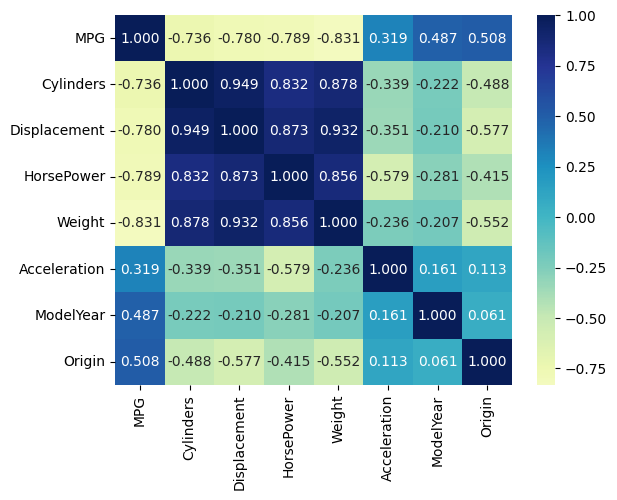

In [21]:
sns.heatmap(df_corr, center= 0, annot=True, fmt='.3f', cmap = 'YlGnBu')

**Q8. Check for potential multicollinearity, which refers to high correlation among the input (independent) variables. Identify the three most correlated variables from the correlation matrix in Q7.<br>**
a) **Cylinders-Displacement**<br>
b) **Weight-Cylinders**<br>
c) HorsePower-Cylinders<br>
d) **Displacement-Weight**<br>
e) Acceleration-HorsePower<br>
f) ModelYear-Origin<br>

**Note: For this question, you will identify the pairs of variables from the heatmap and select those with high correlation.**

#### More data preparation

**Create dummy variables for 'Origin' column.**<br>
Since **'Origin'** is a categorical variable, we will create two columns to represent it in **binary** format.<br>
Use the `pd.get_dummies()` functions as below and save the output in a new DataFrame. You will see that two new columns are created with binary representation for Origin = 2 and 3. Note that, we just need two columns to represent 3 levels. When both these columns have a value of 0, it is implicit that Origin = 1 <br>
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html <br>


In [22]:
#help code below to show usage of get_dummies()
# drop_first=True -> dummy encoding
# drop_first=False -> one hot encoding
auto1 = pd.get_dummies(auto, columns = ['Origin'], drop_first= True, dtype=int)

In [23]:
auto1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           276 non-null    float64
 1   Cylinders     276 non-null    int64  
 2   Displacement  276 non-null    int64  
 3   HorsePower    276 non-null    float64
 4   Weight        276 non-null    int64  
 5   Acceleration  276 non-null    float64
 6   ModelYear     276 non-null    int64  
 7   CarName       276 non-null    object 
 8   Origin_2      276 non-null    int64  
 9   Origin_3      276 non-null    int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 21.7+ KB


### Develop the Multiple Linear Regression Model

**Run a Multiple Linear Regression(MLR) model with 'MPG' as target and all the independent variables.There will be 8 input variables excluding Car Name(Think about why we exclude Car Name). Include the binary columns created for Origin. Follow these steps to build the model -**<br>
 - Create the X(predictor variables) and y(target variable) separately
 - Partition the data into test and train sets with 20% test size, use random_state = 100
 - Then fit the MLR model
 - Find the intercept and regression coefficients.

In [24]:
# Get the column names
auto1.columns

Index(['MPG', 'Cylinders', 'Displacement', 'HorsePower', 'Weight',
       'Acceleration', 'ModelYear', 'CarName', 'Origin_2', 'Origin_3'],
      dtype='object')

In [25]:
# put appropriate columns into X and y
X = auto1[['Cylinders', 'Displacement', 'HorsePower', 'Weight','Acceleration', 'ModelYear', 'Origin_2', 'Origin_3']]
y = auto1['MPG']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 100)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
# Import library and fit a model
lm = LinearRegression()

In [30]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Q9. What is the value of y-intercept of the MLR?  Round the answer to three decimal places.<br>**

In [31]:
print(lm.intercept_)

-22.995346318092064


**Inspect the coefficients**<br>

In [32]:
pd.DataFrame(lm.coef_, X.columns, columns=['Coefficients'])

,Coefficients
Cylinders,0.089539
Displacement,0.024872
HorsePower,-0.044353
Weight,-0.008045
Acceleration,0.147769
ModelYear,0.866426
Origin_2,2.824481
Origin_3,2.642697


#### Make predictions on test data

Now using the test dataset to predict and evaluate the model.

In [33]:
# Write the code to use the model to make predictions on the test dataset.
y_pred = lm.predict(X_test)

#### Evaluate the Model's Performance 

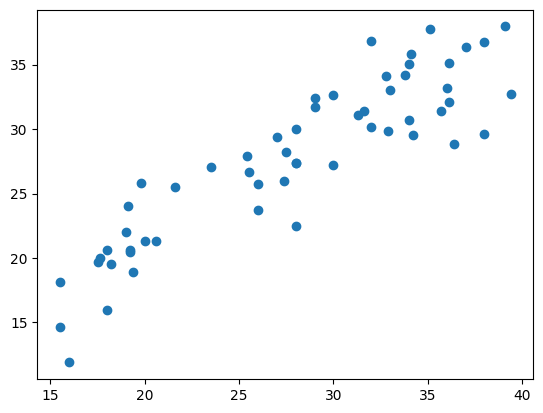

In [34]:
# Evaluate visually - Plot a scatter plot of actual y and predicted y
plt.scatter(y_test, y_pred)

**Q10. What is the RMSE of the model (using test dataset)? Round the answer to two decimal places**

In [35]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [36]:
# Evaluate using MSE and RMSE
# Compute MSE and RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE is : ", round(rmse,2))

RMSE is :  3.11


**Q11. What is the R-squared of the model (using test dataset)? Round the answer to two decimals**

In [37]:
# Compute R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared is :", round(r2, 2))

R-squared is : 0.81


#### Check Residual Plot

Create a DataFrame named `results` and obtain the actual y, predicted y, and residuals for the **trained model**.<br>
Plot a scatter plot of predicted values (on the Horizontal axis) and residual (on the Vertical axis).<br>

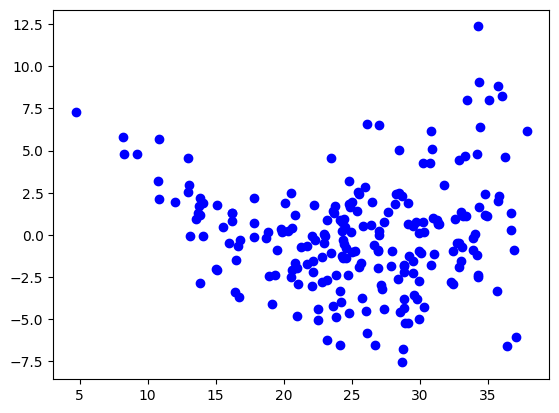

In [38]:
y_model_pred = lm.predict(X_train)

results = pd.DataFrame({'Actual': y_train, 'Predicted': y_model_pred})
results['residuals'] = results['Actual'] - results['Predicted']
plt.scatter(results['Predicted'], results['residuals'],  color='blue')

**Q12. Given that there are issues with the residual plot, what are the possible assumption violation which you can observe from the plot? Select all that apply. <br>**

a) Linearity assumption appears to be violated<br>
b) Independence assumption appears to be violated<br>
c) Normality assumption appears to be violated<br>
d) Equal Variance assumption appears to be violated<br>
<br>

### Transform the y variable, Fit Model 2, Check Residual and report R-squared (of test dataset)

**Since we see issues with the residual plot, let's try a log trasformation on the **mpg** column and build Model 2 with log(MPG) as target'.**<br>

1. First create a new column `log_mpg` which has log of y values
2. Create a train_test_split() again with `log_mpg` instead of y, 20% test data and random_state = 100
3. Fit the Linear regression model
4. Check the residual plot to ensure that the residuals look random
5. Predict on the test data
6. Find the R-squared (of the test data) of Model 2

In [53]:
# Create a new column log_mpg, recall the DataFrame is auto1
# helping code: auto1[<new target variable name>]  = np.log(auto1[<Enter the original target variable>])
auto1['log_mpg']  = np.log(auto1['MPG'])
auto1

,MPG,Cylinders,Displacement,HorsePower,Weight,Acceleration,ModelYear,CarName,Origin_2,Origin_3,log_mpg
0,27.0,4,97,88.00,2130,14.5,71,datsun pl510,0,1,3.295837
1,28.0,4,140,90.00,2264,15.5,71,chevrolet vega 2300,0,0,3.332205
2,25.0,4,113,95.00,2228,14.0,71,toyota corona,0,1,3.218876
3,25.0,4,98,70.87,2046,19.0,71,ford pinto,0,0,3.218876
4,21.0,4,120,87.00,2979,19.5,72,peugeot 504 (sw),1,0,3.044522
...,...,...,...,...,...,...,...,...,...,...,...
271,27.0,4,140,86.00,2790,15.6,82,ford mustang gl,0,0,3.295837
272,44.0,4,97,52.00,2130,24.6,82,vw pickup,1,0,3.784190
273,32.0,4,135,84.00,2295,11.6,82,dodge rampage,0,0,3.465736
274,28.0,4,120,79.00,2625,18.6,82,ford ranger,0,0,3.332205


In [54]:
#Create a train_test_split() again using the right variables
X2 = auto1[['Cylinders', 'Displacement', 'HorsePower', 'Weight','Acceleration', 'ModelYear', 'Origin_2', 'Origin_3']]
y2 = auto1['log_mpg']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y2, test_size = 0.2, random_state = 100)

In [55]:
# Fit the Linear Regression Model
lm2 = LinearRegression()
lm2.fit(X_train2, y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


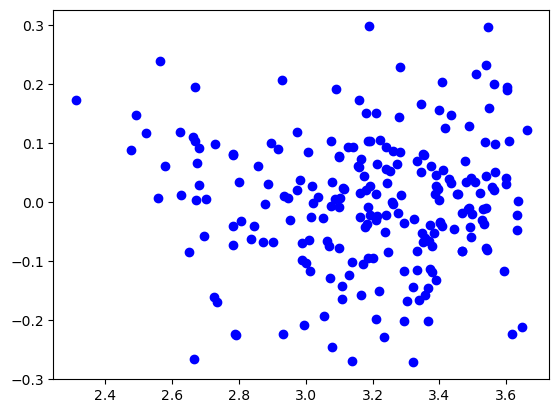

In [56]:
#Check the residual plot to ensure that the residuals look random
y_model_pred2 = lm2.predict(X_train2)

results2 = pd.DataFrame({'Actual': y_train2, 'Predicted': y_model_pred2})
results2['residuals'] = results2['Actual'] - results2['Predicted']
plt.scatter(results2['Predicted'], results2['residuals'],  color='blue')

In [57]:
# Predict on Test Data
y_pred2 = lm2.predict(X_test2)

**Q13. What is the R-squared value (using test dataset) of the updated MLR Model 2? Enter the answer to two decimals.**


In [58]:
# Find the R-squared (using the test data) of Model 2
r_square2 = r2_score(y_test2, y_pred2)
print("R-squared is :", round(r_square2, 2))

R-squared is : 0.85


**Q14. Find the p values of the input variables for Model 2. Based on p-values identify the input variable/s that are not significant at 5% significance level. Select all that apply.**<br>
a) Cylinders<br>
b) Displacement<br>
c) HorsePower<br>
d) Weight<br>
e) Acceleration<br>
f) ModelYear<br>
g) Origin_2


In [59]:
import statsmodels.api as sm

In [60]:
# Use OLS in statsmodels library to find the variables which are not insignificant. 
# Remember that you must train a model with intercept.

X_train_const = sm.add_constant(X_train2)
model2 = sm.OLS(y_train2,X_train_const)
model_result = model2.fit()
model_result.summary2()

# Alternative code to get only the p-value column
#p_values = model_result.summary2().tables[1]['P>|t|']
#print(round(p_values, 2))

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:              OLS              Adj. R-squared:     0.865    
Dependent Variable: log_mpg          AIC:                -325.0166
Date:               2026-02-27 14:31 BIC:                -294.4740
No. Observations:   220              Log-Likelihood:     171.51   
Df Model:           8                F-statistic:        176.6    
Df Residuals:       211              Prob (F-statistic): 4.38e-89 
R-squared:          0.870            Scale:              0.012839 
-------------------------------------------------------------------
                Coef.   Std.Err.     t     P>|t|    [0.025   0.975]
-------------------------------------------------------------------
const           1.4959    0.2511   5.9580  0.0000   1.0009   1.9908
Cylinders      -0.0094    0.0160  -0.5859  0.5586  -0.0410   0.0222
Displacement    0.0006    0.0004   1.4179  0.1577  -0.0002   0.0014
HorsePower     -0.0020    0.0008  -2.5527  0.0114  -0.0036  -0.0005
Weight         -0.0003    0.0000  -8.1569  0.0000  -0.0004  -0.0002
Acceleration    0.0036    0.0046   0.7838  0.4340  -0.0055   0.0128
ModelYear       0.0328    0.0028  11.7589  0.0000   0.0273   0.0383
Origin_2        0.0745    0.0243   3.0637  0.0025   0.0266   0.1225
Origin_3        0.0744    0.0245   3.0379  0.0027   0.0261   0.1227
------------------------------------------------------------------
Omnibus:              0.332         Durbin-Watson:           1.929
Prob(Omnibus):        0.847         Jarque-Bera (JB):        0.270
Skew:                 -0.086        Prob(JB):                0.874
Kurtosis:             2.995         Condition No.:           96722
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 9.67e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

**Q15. Find the VIF values for the input variables in Model 2. Identify the top three variables that indicate potential multicollinearity.<br>**
a) Cylinders<br>
b) Displacement<br>
c) HorsePower<br>
d) Weight<br>
e) Acceleration<br>
f) ModelYear<br>
g) Origin_2


In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [63]:
# VIF computation

for i in range(1,9):
    v = vif(X_train_const.values, i)
    print("VIF for {}:{}".format(X_train_const.columns[i], round(v, 4)))

VIF for Cylinders:10.828
VIF for Displacement:23.6764
VIF for HorsePower:9.5998
VIF for Weight:11.2626
VIF for Acceleration:2.4394
VIF for ModelYear:1.1291
VIF for Origin_2:1.6224
VIF for Origin_3:1.7265


**For learning purposes:** Based on the results above, the linear regression model can be improved by removing insignificant variables to achieve a **parsimonious model**. Additionally, eliminating variables with multicollinearity can further refine it. This process is iterative—train, evaluate, refine, and repeat. For this exercise, we will stop here, but an analyst can continue refining the model.